# Práctica guiada: aprendizaje no supervisado con Wine Clustering

En esta práctica vas a aplicar técnicas de **aprendizaje no supervisado** al dataset `wine-clustering.csv`.

## Objetivos
- Explorar un conjunto de datos sin etiquetas.
- Preparar los datos correctamente.
- Aplicar **K-Means** con distintos valores de `k`.
- Utilizar el **método del codo** y el **silhouette score**.
- Interpretar los clusters obtenidos.

> Completa las celdas y responde a las cuestiones planteadas.


## 1. Carga del dataset

Carga el archivo CSV en un DataFrame llamado `df` y muestra las primeras filas.


In [2]:
import pandas as pd

# Escribe aquí tu código
df = pd.read_csv("wine-clustering.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 2. Primer análisis del dataset

Obtén:
- número de filas y columnas;
- tipos de datos;
- estadísticos descriptivos.

### Cuestión
¿Todas las variables son numéricas? ¿Hay diferencias importantes de escala entre unas columnas y otras?
-   Con el metodo shape nos muestra el tipo de cada columna, en este caso son todas numericas las variables.
-   Hay diferencias de escala entre unas columnas y otras, como por ejemplo 


In [5]:
# Escribe aquí tu código
print(df.shape)
print(df.dtypes)
print(df.describe())

(178, 13)
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object
          Alcohol  Malic_Acid         Ash  Ash_Alcanity   Magnesium  \
count  178.000000  178.000000  178.000000    178.000000  178.000000   
mean    13.000618    2.336348    2.366517     19.494944   99.741573   
std      0.811827    1.117146    0.274344      3.339564   14.282484   
min     11.030000    0.740000    1.360000     10.600000   70.000000   
25%     12.362500    1.602500    2.210000     17.200000   88.000000   
50%     13.050000    1.865000    2.360000     19.500000   98.000000   
75%     13.677500    3.082500    2.557500     21.500000  107.00

In [16]:
df.corr(numeric_only=True)["Alcohol"].abs().sort_values(ascending=False)[1:]

Proline                 0.643720
cluster                 0.600101
Color_Intensity         0.546364
Ash_Alcanity            0.310235
Total_Phenols           0.289101
Magnesium               0.270798
Flavanoids              0.236815
Ash                     0.211545
Nonflavanoid_Phenols    0.155929
Proanthocyanins         0.136698
Malic_Acid              0.094397
OD280                   0.072343
Hue                     0.071747
Name: Alcohol, dtype: float64

## 3. Preprocesamiento

Aplica un escalado con `StandardScaler`.

### Cuestión
¿Por qué es importante escalar los datos antes de aplicar K-Means?

Es fundamental porque K-Means se basa en el cálculo de distancias para agrupar los datos. Si no se escalan, las variables con rangos numéricos más grandes (como Proline) dominarán el cálculo de la distancia, haciendo que las variables con rangos pequeños (como Hue o Alcohol) no tengan prácticamente influencia en la formación de los clusters, aunque sean igual de importantes para definir el tipo de vino. El escalado asegura que todas las características contribuyan por igual.

In [7]:
from sklearn.preprocessing import StandardScaler

# Crea una variable X con las columnas del dataset
# Después escala los datos y guarda el resultado en X_scaled

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Prueba distintos valores de k

Calcula la **inercia** y el **silhouette score** para valores de `k` entre 2 y 10.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
valores_k = range(2, 11)

# Completa el bucle
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X) 

    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

## 5. Representa el método del codo

Haz una gráfica de `k` frente a `inercia`.

### Cuestión
¿En qué valor de `k` parece producirse el “codo”?
-   Se ve que el “codo” está más o menos entre k = 4 y k = 5. Hasta ahí la inercia baja bastante rápido, pero a partir de ese punto la curva empieza a “aplanarse”, o sea, añadir más clusters ya no mejora mucho. Si tuviera que elegir uno solo, me quedaría con k = 4, porque ahí es donde el cambio fuerte ya empieza a frenarse.

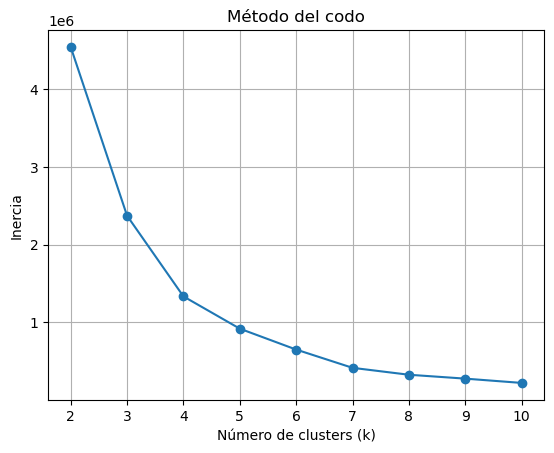

In [9]:
import matplotlib.pyplot as plt

# Escribe aquí tu código
import matplotlib.pyplot as plt

plt.figure()
plt.plot(valores_k, inercias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.xticks(valores_k)
plt.grid(True)
plt.show()

## 6. Representa el silhouette score

Haz una gráfica de `k` frente a `silhouette`.

### Cuestión
¿Qué valor de `k` obtiene el mejor resultado?
-   Con k igual a 3, obtenemos el mejor resultado.


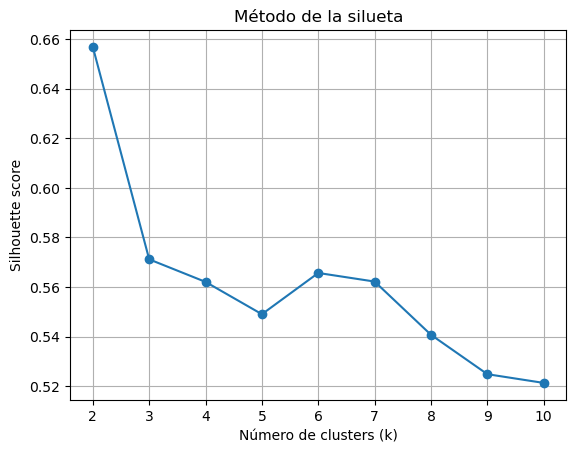

In [10]:
# Escribe aquí tu código
import matplotlib.pyplot as plt

plt.figure()
plt.plot(valores_k, silhouettes, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Método de la silueta')
plt.xticks(valores_k)
plt.grid(True)
plt.show()


## 7. Entrena el modelo final

Elige el valor de `k` que consideres más adecuado y entrena un modelo final de K-Means.

Guarda las etiquetas de cluster en una nueva columna llamada `cluster`.


In [11]:
# Escribe aquí tu código
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_final.fit(X)

# Guardar etiquetas en el DataFrame
df['cluster'] = kmeans_final.labels_

## 8. Evalúa el modelo

Calcula el **silhouette score** del modelo final.

### Cuestión
¿Te parece un resultado bueno, aceptable o bajo? Razona tu respuesta.

En este dataset, un silhouette score cercano a 0.3-0.5 se considera aceptable, indicando que existe una estructura de grupos definida, aunque con cierto solapamiento entre ellos.


In [12]:
# Escribe aquí tu código
score = silhouette_score(X, kmeans_final.labels_)
print("Silhouette score:", score)

Silhouette score: 0.5595865058689159


## 9. Analiza el tamaño de los clusters

Cuenta cuántos registros hay en cada cluster.


In [13]:
# Escribe aquí tu código
df['cluster'].value_counts()

cluster
0    102
1     49
2     27
Name: count, dtype: int64

## 10. Interpreta los clusters

Calcula la media de cada variable por cluster.

### Cuestiones
1. ¿Qué variables parecen diferenciar más unos clusters de otros?
-   Según la comparación de las medias de cada grupo y la estructura del dataset, las variables que muestran diferencias más drásticas entre los clusters son:

    Proline: Es la variable con mayor rango de diferencia. El cluster con mayor contenido alcohólico suele tener valores de Proline muy superiores (media >1000) frente a los otros grupos (medias <600).

    Color_Intensity: Separa claramente los vinos más intensos y oscuros de los más claros y suaves.

    Flavanoids y Total_Phenols: Los niveles de antioxidantes y compuestos fenólicos son significativamente más altos en un grupo específico, mientras que otro grupo (posiblemente los vinos de menor calidad o tipo diferente) presenta niveles muy bajos.

    Alcohol: Aunque todas varían, el grado alcohólico marca una tendencia clara: vinos de alta graduación vs. vinos más ligeros.

2. ¿Qué perfil de vino podría representar cada grupo?
-   Cluster 0 (Vinos Premium/Potentes): Representa vinos con alto contenido de alcohol y una concentración muy elevada de Proline. Tienen una intensidad de color alta y una gran cantidad de flavonoides. Serían vinos con mucho cuerpo, complejos y probablemente de mayor precio o crianza.

-   Cluster 1 (Vinos Ligeros/Suaves): Este grupo incluye vinos con menor graduación alcohólica y baja intensidad de color. Tienen niveles moderados de fenoles y una alcalinidad de la ceniza más alta. Se perfilan como vinos más frescos, fáciles de beber y menos estructurados.

-   Cluster 2 (Vinos de Perfil Bajo/Amargos): Se caracterizan por tener los niveles más bajos de flavonoides y de Hue (tonalidad), junto con una alta intensidad de color pero de baja calidad cromática. Presentan una mayor concentración de ácido málico, lo que sugiere un perfil más ácido o menos equilibrado que los anteriores.


In [14]:
# Escribe aquí tu código
df.groupby('cluster').mean()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
cluster,,,,,,,,,,,,,
0,12.598529,2.453431,2.321863,20.646078,93.696078,2.053627,1.647549,0.395980,1.425098,4.673333,0.917843,2.394804,521.558824
1,13.369184,2.400000,2.392653,18.514286,109.081633,2.441633,2.213673,0.325510,1.706735,5.188367,0.959714,2.847959,906.346939
2,13.850741,1.778519,2.487778,16.925926,105.629630,2.941481,3.136667,0.298889,2.007037,6.275185,1.102963,3.002222,1308.777778


## 11. Reflexión final

Responde brevemente:

1. ¿En qué se diferencia el aprendizaje supervisado del no supervisado?
    -   La diferencia principal radica en la presencia de etiquetas. En el aprendizaje supervisado, el modelo entrena con 
        datos que ya tienen la respuesta correcta (etiquetas), mientras que en el no supervisado (como este caso de clustering), 
        el algoritmo busca patrones o estructuras ocultas en los datos por sí solo, sin conocer categorías previas.

2. ¿Por qué K-Means no siempre encuentra la mejor solución posible?
    -   Principalmente porque es sensible a la inicialización aleatoria de los centroides (puede caer en mínimos locales) 
        y porque requiere que el usuario defina previamente el número de clusters (k), el cual no siempre es obvio. Además, 
        asume que los clusters son esféricos y de tamaño similar, lo cual no siempre ocurre en datos reales.

3. ¿Qué papel juega el preprocesamiento en este problema?
    -   Es el paso que garantiza la equidad entre variables. Al aplicar StandardScaler, transformamos los datos para que 
        tengan media 0 y desviación estándar 1, evitando que variables con escalas grandes distorsionen los grupos. Sin 
        preprocesamiento, el clustering solo reflejaría las diferencias en la variable Proline.

4. ¿Qué limitaciones observas en K-Means cuando se aplica a datos reales?
    -   Sensibilidad a valores atípicos (outliers): Pueden desplazar los centroides drásticamente.
    -   Dificultad con formas complejas: No funciona bien si los grupos tienen formas alargadas o irregulares (no esféricas).
    -   Número de grupos desconocido: En la vida real, rara vez sabemos cuántos segmentos naturales existen realmente, y métricas como el método del codo pueden ser ambiguas.
